In [7]:
import pandas as pd

path = r"C:\Users\Fabíola\Dropbox\DIPF_Projetos\Workshop_JTELSS\breathingJTEL.csv"
df = pd.read_csv(path, sep=";")


In [8]:
import matplotlib.pyplot as plt 

In [9]:
df.groupby("group")["final_exam_grade"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
A,31.0,70.354839,9.024221,45.0,69.00,71.0,71.50,90.0
B,32.0,71.125000,3.024097,65.0,69.00,71.0,74.00,76.0
C,36.0,82.944444,4.153790,74.0,80.75,83.0,85.25,90.0


In [10]:
df.groupby("group")[["stress_level", "heart_rate", "engagement_score"]].describe()

stress_level                                               heart_rate  \
             count      mean       std  min  25%  50%  75%   max      count   
group                                                                         
A             30.0  5.233333  0.430183  5.0  5.0  5.0  5.0   6.0       30.0   
B             32.0  7.281250  0.456803  7.0  7.0  7.0  8.0   8.0       32.0   
C             36.0  4.305556  2.702585  1.0  3.0  3.0  4.0  10.0       36.0   

                  ...              engagement_score                       \
            mean  ...    75%   max            count       mean       std   
group             ...                                                      
A      78.133333  ...  82.00  83.0             31.0  69.096774  2.856044   
B      91.687500  ...  93.50  98.0             32.0  57.218750  2.536627   
C      72.916667  ...  72.25  99.0             36.0  78.250000  3.729228   

                                       
        min    25%   50%    75%   max  
group                                  
A      65.0  67.00  69.0  72.00  74.0  
B      52.0  55.75  58.0  58.25  62.0  
C      70.0  76.00  78.0  81.00  84.0  

[3 rows x 24 columns]

In [11]:
df[["blood_pressure_systolic", "blood_pressure_diastolic"]] = df["blood_pressure"].str.split("/", expand=True).astype(float)
df.groupby("group")[["blood_pressure_systolic", "blood_pressure_diastolic"]].describe()

blood_pressure_systolic                                              \
                        count        mean       std    min     25%    50%   
group                                                                       
A                        30.0  121.733333  2.227312  118.0  120.25  121.5   
B                        32.0  135.750000  3.464102  130.0  133.00  137.0   
C                        36.0  118.444444  8.047873  112.0  114.00  117.0   

                     blood_pressure_diastolic                             \
          75%    max                    count       mean       std   min   
group                                                                      
A      123.75  125.0                     30.0  79.066667  2.273283  76.0   
B      139.00  140.0                     32.0  88.531250  2.539804  85.0   
C      118.00  140.0                     36.0  76.555556  3.835507  72.0   

                                
        25%   50%    75%   max  
group                           
A      77.0  79.0  81.75  82.0  
B      86.0  88.0  91.00  92.0  
C      74.0  76.0  77.25  86.0

In [12]:
df.groupby(["participant_id", "group"])[["stress_level", "heart_rate", "engagement_score"]].mean()

,,stress_level,heart_rate,engagement_score
participant_id,group,,,
P01,A,5.25,79.25,70.750000
P02,A,5.00,76.50,69.500000
P03,A,5.00,82.00,69.000000
P04,A,5.25,78.25,67.000000
P05,A,5.25,81.25,68.000000
P06,A,5.25,77.75,67.750000
P07,A,5.75,77.50,71.333333
P08,A,5.00,74.50,70.000000
P09,B,7.50,91.50,58.250000


In [13]:
df.groupby(["group", "measurement_period"])[["final_exam_grade", "stress_level", "heart_rate", "engagement_score"]].mean() 

final_exam_grade  stress_level  heart_rate  \
group measurement_period                                               
A     1                          65.875000      5.250000   78.000000   
      2                          69.750000      5.285714   78.428571   
      3                          70.750000      5.142857   78.571429   
      4                          75.714286      5.250000   77.625000   
B     1                          69.125000      7.000000   92.500000   
      2                          70.625000      7.625000   91.375000   
      3                          72.000000      7.250000   91.375000   
      4                          72.750000      7.250000   91.500000   
C     1                          78.111111      8.111111   80.222222   
      2                          82.000000      3.000000   69.444444   
      3                          84.555556      3.000000   71.111111   
      4                          87.111111      3.111111   70.888889   

                          engagement_score  
group measurement_period                    
A     1                          68.250000  
      2                          67.000000  
      3                          69.500000  
      4                          72.000000  
B     1                          55.000000  
      2                          57.375000  
      3                          58.250000  
      4                          58.250000  
C     1                          74.666667  
      2                          77.666667  
      3                          79.888889  
      4                          80.777778

In [14]:
means = df.groupby(["measurement_period", "group"])[["final_exam_grade", "stress_level", "heart_rate", "engagement_score"]].mean()

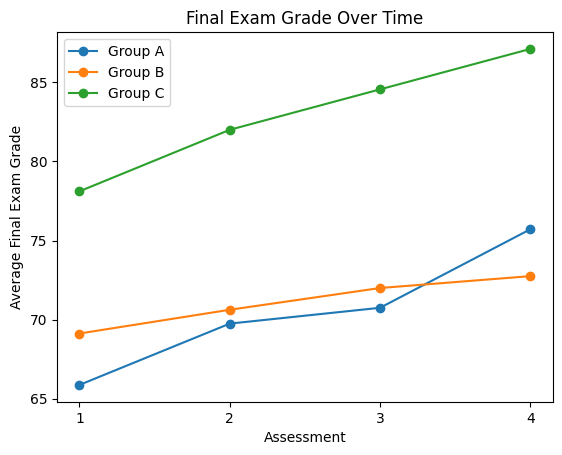

In [15]:
# Grade
for group in means.index.get_level_values("group").unique():
    subset = means.xs(group, level="group")
    plt.plot(subset.index, subset["final_exam_grade"],marker="o",label=f"Group {group}")

plt.title("Final Exam Grade Over Time")
plt.xlabel("Assessment")
plt.ylabel("Average Final Exam Grade")

plt.xticks([1, 2, 3, 4])
plt.legend()
plt.show()

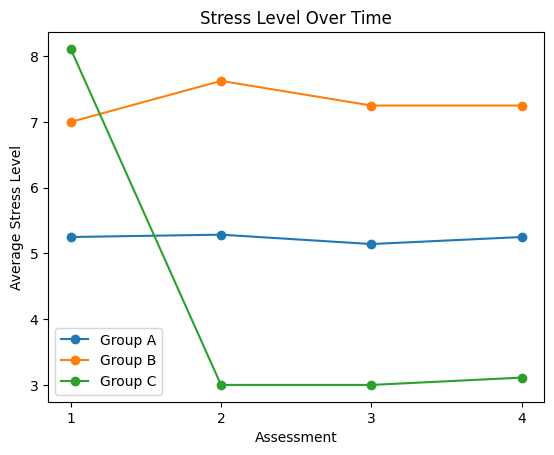

In [16]:
# Stress
for group in means.index.get_level_values("group").unique():
    subset = means.xs(group, level="group")
    plt.plot(subset.index, subset["stress_level"], marker="o",label=f"Group {group}"
    )

plt.title("Stress Level Over Time")
plt.xlabel("Assessment")
plt.ylabel("Average Stress Level")

plt.xticks([1, 2, 3, 4])
plt.legend()
plt.show()

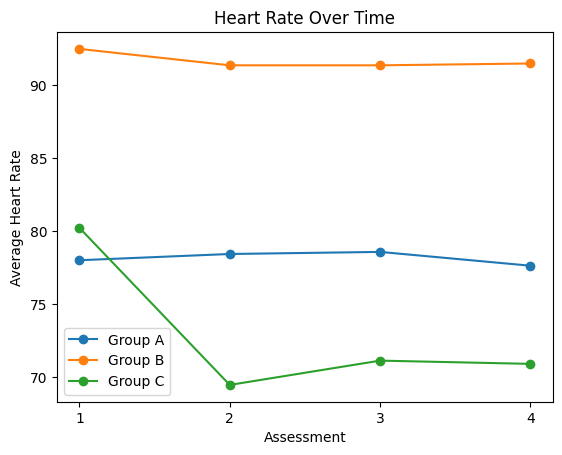

In [17]:
# Heart Rate
for group in means.index.get_level_values("group").unique():
    subset = means.xs(group, level="group")
    plt.plot( subset.index, subset["heart_rate"], marker="o", label=f"Group {group}")

plt.title("Heart Rate Over Time")
plt.xlabel("Assessment")
plt.ylabel("Average Heart Rate")

plt.xticks([1, 2, 3, 4])
plt.legend()
plt.show()

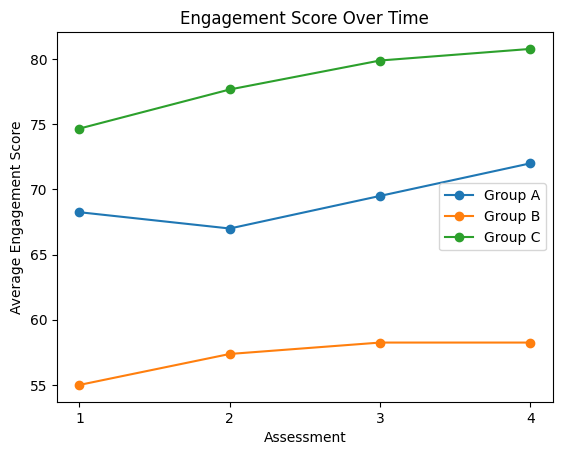

In [18]:
# Engagement 
for group in means.index.get_level_values("group").unique():
    subset = means.xs(group, level="group")
    plt.plot(subset.index, subset["engagement_score"], marker="o", label=f"Group {group}")

plt.title("Engagement Score Over Time")
plt.xlabel("Assessment")
plt.ylabel("Average Engagement Score")

plt.xticks([1, 2, 3, 4])
plt.legend()
plt.show()